In [1]:
import numpy as np

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha = 0.1
nx    = 20
nt    = 100
x     = np.linspace(0, 1, nx)
dx    = x[1] - x[0]

r     = 0.4                      # CFL number
dt    = r * dx**2 / alpha

print(f"dx = {dx:.6f}")
print(f"dt = {dt:.6f}")
print(f"CFL r = alpha*dt/dx^2 = {alpha*dt/dx**2:.4f}")

# ─────────────────────────────────────────────
# Pick one target point: interior, second time step
# target: (x*, t*) = (x[5], t[1])
# ─────────────────────────────────────────────
j_star = 5          # spatial index
k_star = 1          # time index (second row, so neighbours are at k=0)

x_star = x[j_star]
t_star = dt * k_star

print(f"\nTarget point: x* = {x_star:.4f},  t* = {t_star:.6f}")

# ─────────────────────────────────────────────
# 3 neighbours (all at previous time step k=0)
# n1: centre  (x*,       t* - dt)
# n2: left    (x* - dx,  t* - dt)
# n3: right   (x* + dx,  t* - dt)
# ─────────────────────────────────────────────
dx_nb = np.array([0.0,  -dx,  +dx])
dt_nb = np.array([-dt,  -dt,  -dt])

print(f"\nNeighbours (relative offsets):")
print(f"  Centre: dx={dx_nb[0]:.4f},  dt={dt_nb[0]:.6f}")
print(f"  Left:   dx={dx_nb[1]:.4f},  dt={dt_nb[1]:.6f}")
print(f"  Right:  dx={dx_nb[2]:.4f},  dt={dt_nb[2]:.6f}")

# ─────────────────────────────────────────────
# Build 3x3 matrix A and solve
# Row 1: consistency     sum(w)       = 1
# Row 2: spatial bias    sum(w*dx)    = 0
# Row 3: diffusion       sum(w*(dt - alpha*dx^2)) = 0
# ─────────────────────────────────────────────
A = np.array([
    [1.0,  1.0,  1.0],
    dx_nb,
    alpha * dt_nb + 0.5 * dx_nb**2
])
b = np.array([1.0, 0.0, 0.0])

print(f"\nMatrix A:")
print(A)
print(f"\nb = {b}")

w = np.linalg.solve(A, b)

# ─────────────────────────────────────────────
# FD weights (explicit Euler)
# u* = (1-2r)*u_c + r*u_l + r*u_r
# ─────────────────────────────────────────────
w_fd = np.array([1 - 2*r, r, r])

print(f"\n─── Weight Comparison ───────────────────────")
print(f"{'':10s}  {'Centre':>12}  {'Left':>12}  {'Right':>12}")
print(f"{'Our w':10s}  {w[0]:>12.8f}  {w[1]:>12.8f}  {w[2]:>12.8f}")
print(f"{'FD w':10s}  {w_fd[0]:>12.8f}  {w_fd[1]:>12.8f}  {w_fd[2]:>12.8f}")
print(f"{'Diff':10s}  {w[0]-w_fd[0]:>12.2e}  {w[1]-w_fd[1]:>12.2e}  {w[2]-w_fd[2]:>12.2e}")

# ─────────────────────────────────────────────
# Apply weights to reconstruct u at target
# ─────────────────────────────────────────────
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

u_nb = np.array([
    u_true(x_star,       t_star - dt),
    u_true(x_star - dx,  t_star - dt),
    u_true(x_star + dx,  t_star - dt),
])

u_pred  = w    @ u_nb
u_fd    = w_fd @ u_nb
u_exact = u_true(x_star, t_star)

print(f"\n─── Reconstruction at target ────────────────")
print(f"u_pred  (our weights) = {u_pred:.8f}")
print(f"u_fd    (FD  weights) = {u_fd:.8f}")
print(f"u_exact (true)        = {u_exact:.8f}")
print(f"Error our vs exact    = {abs(u_pred  - u_exact):.4e}")
print(f"Error FD  vs exact    = {abs(u_fd    - u_exact):.4e}")
print(f"Error our vs FD       = {abs(u_pred  - u_fd):.4e}")

dx = 0.052632
dt = 0.011080
CFL r = alpha*dt/dx^2 = 0.4000

Target point: x* = 0.2632,  t* = 0.011080

Neighbours (relative offsets):
  Centre: dx=0.0000,  dt=-0.011080
  Left:   dx=-0.0526,  dt=-0.011080
  Right:  dx=0.0526,  dt=-0.011080

Matrix A:
[[ 1.00000000e+00  1.00000000e+00  1.00000000e+00]
 [ 0.00000000e+00 -5.26315789e-02  5.26315789e-02]
 [-1.10803324e-03  2.77008310e-04  2.77008310e-04]]

b = [1. 0. 0.]

─── Weight Comparison ───────────────────────
                  Centre          Left         Right
Our w         0.20000000    0.40000000    0.40000000
FD w          0.20000000    0.40000000    0.40000000
Diff            0.00e+00      0.00e+00      0.00e+00

─── Reconstruction at target ────────────────
u_pred  (our weights) = 0.72769646
u_fd    (FD  weights) = 0.72769646
u_exact (true)        = 0.72772198
Error our vs exact    = 2.5520e-05
Error FD  vs exact    = 2.5520e-05
Error our vs FD       = 0.0000e+00


dx = 0.0526,  dt = 0.011080,  CFL r = alpha*dt/dx^2 = 0.4000
T  = 1.0970

─── Step 1: Weight Recovery ───────────────────
                          centre        left       right
Our weights             0.200000    0.400000    0.400000
FD weights              0.200000    0.400000    0.400000
Difference              0.00e+00    0.00e+00    0.00e+00

─── Step 2: Full Rollout Error ─────────────────
Our vs True  — mean: 5.2427e-04  max: 1.1738e-03
FD  vs True  — mean: 5.2427e-04  max: 1.1738e-03
Our vs FD    — mean: 5.9890e-17  max: 3.3307e-16


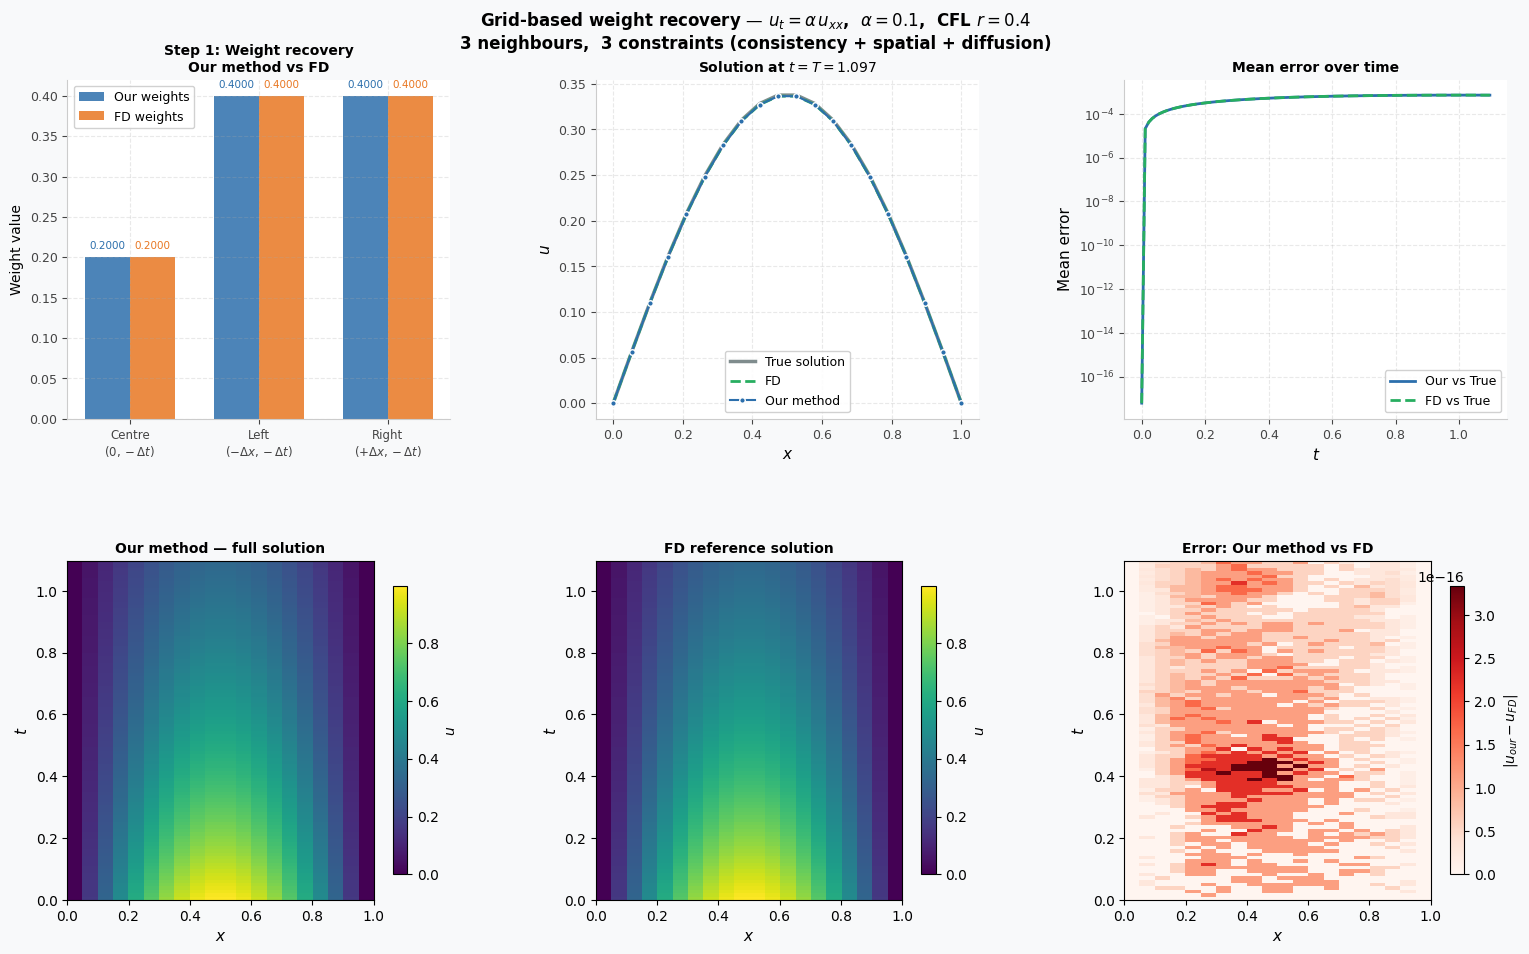

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha = 0.1
nx    = 20
nt    = 100
x     = np.linspace(0, 1, nx)
dx    = x[1] - x[0]

# pick dt to satisfy CFL
r     = 0.4                  # CFL numxber we want
dt    = r * dx**2 / alpha
t     = np.linspace(0, dt * (nt - 1), nt)
T     = t[-1]

print(f"dx = {dx:.4f},  dt = {dt:.6f},  CFL r = alpha*dt/dx^2 = {alpha*dt/dx**2:.4f}")
print(f"T  = {T:.4f}")

# ─────────────────────────────────────────────
# True solution
# ─────────────────────────────────────────────
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# ─────────────────────────────────────────────
# FD reference solution (explicit Euler)
# ─────────────────────────────────────────────
U_fd = np.zeros((nt, nx))
U_fd[0, :] = u_true(x, 0)
U_fd[:, 0] = 0.0
U_fd[:,-1] = 0.0
for k in range(nt - 1):
    U_fd[k+1, 1:-1] = (U_fd[k, 1:-1]
                       + r * (U_fd[k, 2:] - 2*U_fd[k, 1:-1] + U_fd[k, :-2]))

# ─────────────────────────────────────────────
# Weight solver
# 3 neighbours: centre, left, right (all at previous time step)
# 3 constraints: consistency, no spatial bias, diffusion
# → exactly determined system
# ─────────────────────────────────────────────
def compute_weights_grid(dx, dt, alpha):
    """
    Neighbours relative to target (x*, t*):
      n1: ( 0,    -dt)   centre, previous time
      n2: (-dx,  -dt)   left,   previous time
      n3: (+dx,  -dt)   right,  previous time

    dx_nb = [0, -dx, +dx]
    dt_nb = [-dt, -dt, -dt]

    Constraints:
      [1, 1, 1]                              w = 1   (consistency)
      [0, -dx, +dx]                          w = 0   (no spatial bias)
      [dt_i - alpha*dx_i^2] for each i      w = 0   (diffusion)
    """
    dx_nb = np.array([0.0, -dx,  +dx])
    dt_nb = np.array([-dt, -dt,  -dt])

    A = np.array([
        [1.0,  1.0,  1.0],
        dx_nb,
        alpha * dt_nb + 0.5 * dx_nb**2
    ])
    b = np.array([1.0, 0.0, 0.0])

    w = np.linalg.solve(A, b)
    return w, dx_nb, dt_nb

w, dx_nb, dt_nb = compute_weights_grid(dx, dt, alpha)

# ─────────────────────────────────────────────
# Compare with known FD weights
# Explicit Euler: u* = (1-2r)*u_c + r*u_l + r*u_r
# ─────────────────────────────────────────────
w_fd = np.array([1 - 2*r, r, r])   # [centre, left, right]

print("\n─── Step 1: Weight Recovery ───────────────────")
print(f"{'':20s}  {'centre':>10}  {'left':>10}  {'right':>10}")
print(f"{'Our weights':20s}  {w[0]:>10.6f}  {w[1]:>10.6f}  {w[2]:>10.6f}")
print(f"{'FD weights':20s}  {w_fd[0]:>10.6f}  {w_fd[1]:>10.6f}  {w_fd[2]:>10.6f}")
print(f"{'Difference':20s}  {w[0]-w_fd[0]:>10.2e}  {w[1]-w_fd[1]:>10.2e}  {w[2]-w_fd[2]:>10.2e}")

# ─────────────────────────────────────────────
# Full rollout using our weights
# ─────────────────────────────────────────────
U_our = np.zeros((nt, nx))
U_our[0, :] = u_true(x, 0)   # IC
U_our[:, 0] = 0.0             # BC left
U_our[:,-1] = 0.0             # BC right

for k in range(nt - 1):
    for j in range(1, nx - 1):
        # neighbours: centre, left, right at time k
        u_nb   = np.array([U_our[k, j], U_our[k, j-1], U_our[k, j+1]])
        U_our[k+1, j] = w @ u_nb

print("\n─── Step 2: Full Rollout Error ─────────────────")
# Compare our rollout vs FD vs true
err_our_vs_true = np.abs(U_our - u_true(*np.meshgrid(x, t)))
err_fd_vs_true  = np.abs(U_fd  - u_true(*np.meshgrid(x, t)))
err_our_vs_fd   = np.abs(U_our - U_fd)

print(f"Our vs True  — mean: {err_our_vs_true.mean():.4e}  max: {err_our_vs_true.max():.4e}")
print(f"FD  vs True  — mean: {err_fd_vs_true.mean():.4e}  max: {err_fd_vs_true.max():.4e}")
print(f"Our vs FD    — mean: {err_our_vs_fd.mean():.4e}  max: {err_our_vs_fd.max():.4e}")

# ─────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────
BLUE   = '#2C6FAC'
RED    = '#C0392B'
GREEN  = '#27AE60'
ORANGE = '#E87722'
GREY   = '#7F8C8D'

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.25, linestyle='--', color='#AAAAAA')

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38,
                        left=0.07, right=0.97, top=0.90, bottom=0.08)

# ── Panel 1: Weight bar chart ─────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
labels = ['Centre\n$(0, -\\Delta t)$', 'Left\n$(-\\Delta x, -\\Delta t)$', 'Right\n$(+\\Delta x, -\\Delta t)$']
xpos   = np.arange(3)
width  = 0.35
ax1.bar(xpos - width/2, w,    width, color=BLUE,  label='Our weights', alpha=0.85)
ax1.bar(xpos + width/2, w_fd, width, color=ORANGE, label='FD weights',  alpha=0.85)
ax1.set_xticks(xpos); ax1.set_xticklabels(labels, fontsize=8.5)
ax1.set_ylabel('Weight value', fontsize=10)
ax1.set_title('Step 1: Weight recovery\nOur method vs FD', fontsize=10, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')
for i, (wo, wf) in enumerate(zip(w, w_fd)):
    ax1.text(i - width/2, wo + 0.01, f'{wo:.4f}', ha='center', fontsize=7.5, color=BLUE)
    ax1.text(i + width/2, wf + 0.01, f'{wf:.4f}', ha='center', fontsize=7.5, color=ORANGE)

# ── Panel 2: Solution at final time ──────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)
ax2.plot(x, u_true(x, T),  '-',  color=GREY,   linewidth=2.5, label='True solution', zorder=3)
ax2.plot(x, U_fd[-1, :],   '--', color=GREEN,   linewidth=2,   label='FD', zorder=4)
ax2.plot(x, U_our[-1, :],  'o-', color=BLUE,    linewidth=1.5, markersize=4,
         label='Our method', zorder=5, markeredgecolor='white')
ax2.set_xlabel('$x$', fontsize=11)
ax2.set_ylabel('$u$', fontsize=11)
ax2.set_title(f'Solution at $t = T = {T:.3f}$', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

# ── Panel 3: Error vs time ────────────────────
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)
err_our_t = err_our_vs_true.mean(axis=1)
err_fd_t  = err_fd_vs_true.mean(axis=1)
ax3.semilogy(t, err_our_t, '-',  color=BLUE,  linewidth=2, label='Our vs True')
ax3.semilogy(t, err_fd_t,  '--', color=GREEN, linewidth=2, label='FD vs True')
ax3.set_xlabel('$t$', fontsize=11)
ax3.set_ylabel('Mean error', fontsize=11)
ax3.set_title('Mean error over time', fontsize=10, fontweight='bold')
ax3.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

# ── Panel 4: Our solution heatmap ────────────
ax4 = fig.add_subplot(gs[1, 0])
im4 = ax4.imshow(U_our, origin='lower', aspect='auto',
                 extent=[0, 1, 0, T], cmap='viridis')
plt.colorbar(im4, ax=ax4, label='$u$', shrink=0.85)
ax4.set_xlabel('$x$', fontsize=11); ax4.set_ylabel('$t$', fontsize=11)
ax4.set_title('Our method — full solution', fontsize=10, fontweight='bold')

# ── Panel 5: FD solution heatmap ─────────────
ax5 = fig.add_subplot(gs[1, 1])
im5 = ax5.imshow(U_fd, origin='lower', aspect='auto',
                 extent=[0, 1, 0, T], cmap='viridis')
plt.colorbar(im5, ax=ax5, label='$u$', shrink=0.85)
ax5.set_xlabel('$x$', fontsize=11); ax5.set_ylabel('$t$', fontsize=11)
ax5.set_title('FD reference solution', fontsize=10, fontweight='bold')

# ── Panel 6: Error heatmap (our vs FD) ───────
ax6 = fig.add_subplot(gs[1, 2])
im6 = ax6.imshow(err_our_vs_fd, origin='lower', aspect='auto',
                 extent=[0, 1, 0, T], cmap='Reds')
plt.colorbar(im6, ax=ax6, label='$|u_{our} - u_{FD}|$', shrink=0.85)
ax6.set_xlabel('$x$', fontsize=11); ax6.set_ylabel('$t$', fontsize=11)
ax6.set_title('Error: Our method vs FD', fontsize=10, fontweight='bold')

fig.suptitle(
    r'Grid-based weight recovery — $u_t = \alpha\,u_{xx}$,  $\alpha=0.1$,  CFL $r=0.4$'
    '\n'
    r'3 neighbours,  3 constraints (consistency + spatial + diffusion)',
    fontsize=12, fontweight='bold', y=0.97
)

plt.savefig('grid_weight_recovery.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [16]:
import numpy as np

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha = 0.1
nx    = 40
x     = np.linspace(0, 1, nx)
dx    = x[1] - x[0]

r     = 0.4
dt    = r * dx**2 / alpha

print(f"dx = {dx:.6f}")
print(f"dt = {dt:.8f}")
print(f"CFL r = alpha*dt/dx^2 = {alpha*dt/dx**2:.4f}")

# ─────────────────────────────────────────────
# Target point
# ─────────────────────────────────────────────
j_star = 10
k_star = 1

x_star = x[j_star]
t_star = dt * k_star

print(f"\nTarget: x* = {x_star:.6f},  t* = {t_star:.8f}")

# ─────────────────────────────────────────────
# 5 neighbours (all at previous time step)
# order: centre, left1, right1, left2, right2
# ─────────────────────────────────────────────
dx_nb = np.array([0.0, -dx, +dx, -2*dx, +2*dx])
dt_nb = np.array([-dt, -dt,  -dt,  -dt,   -dt])

print(f"\nNeighbours (Δx, Δt):")
labels = ['Centre', 'Left 1', 'Right 1', 'Left 2', 'Right 2']
for lab, dxi, dti in zip(labels, dx_nb, dt_nb):
    print(f"  {lab:8s}: dx={dxi:+.6f},  dt={dti:.8f}")

# ─────────────────────────────────────────────
# Build 5x5 matrix
# Row 1: consistency
# Row 2: kills u_x
# Row 3: PDE constraint  (½ Δx² - α Δt)
# Row 4: kills u_xxx
# Row 5: kills u_xxxx  → gives 4th order
# ─────────────────────────────────────────────
A = np.array([
    np.ones(5),
    dx_nb,
    0.5 * dx_nb**2 + alpha * dt_nb,
    dx_nb**3 / 6,
    dx_nb**4 / 24,
])
b = np.array([1.0, 0.0, 0.0, 0.0, 0.0])

print(f"\nMatrix A:")
print(np.array2string(A, formatter={'float_kind': lambda x: f'{x:+.6e}'}))
print(f"\nb = {b}")

w = np.linalg.solve(A, b)

# ─────────────────────────────────────────────
# Theoretical 4th order FD weights
# u* = (1 - 5r/2)*u_c + (4r/3)*(u_l1+u_r1) + (-r/12)*(u_l2+u_r2)
# ─────────────────────────────────────────────
w_fd = np.array([
    1 - 5*r/2,      # centre
     4*r/3,         # left 1
     4*r/3,         # right 1
    -r/12,          # left 2
    -r/12,          # right 2
])

print(f"\n─── Weight Comparison ──────────────────────────────────────")
print(f"{'':12s}  {'Centre':>14}  {'Left 1':>14}  {'Right 1':>14}  {'Left 2':>14}  {'Right 2':>14}")
print(f"{'Our w':12s}  {w[0]:>14.8f}  {w[1]:>14.8f}  {w[2]:>14.8f}  {w[3]:>14.8f}  {w[4]:>14.8f}")
print(f"{'FD w':12s}  {w_fd[0]:>14.8f}  {w_fd[1]:>14.8f}  {w_fd[2]:>14.8f}  {w_fd[3]:>14.8f}  {w_fd[4]:>14.8f}")
print(f"{'Diff':12s}  {w[0]-w_fd[0]:>14.2e}  {w[1]-w_fd[1]:>14.2e}  {w[2]-w_fd[2]:>14.2e}  {w[3]-w_fd[3]:>14.2e}  {w[4]-w_fd[4]:>14.2e}")

# ─────────────────────────────────────────────
# Reconstruct u at target
# ─────────────────────────────────────────────
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

u_nb = np.array([
    u_true(x_star,          t_star - dt),
    u_true(x_star - dx,     t_star - dt),
    u_true(x_star + dx,     t_star - dt),
    u_true(x_star - 2*dx,   t_star - dt),
    u_true(x_star + 2*dx,   t_star - dt),
])

u_pred  = w    @ u_nb
u_fd    = w_fd @ u_nb
u_exact = u_true(x_star, t_star)

print(f"\n─── Reconstruction at target ───────────────────────────────")
print(f"u_pred  (our weights) = {u_pred:.10f}")
print(f"u_fd    (FD  weights) = {u_fd:.10f}")
print(f"u_exact (true)        = {u_exact:.10f}")
print(f"Error our vs exact    = {abs(u_pred  - u_exact):.4e}")
print(f"Error FD  vs exact    = {abs(u_fd    - u_exact):.4e}")
print(f"Error our vs FD       = {abs(u_pred  - u_fd):.4e}")

dx = 0.025641
dt = 0.00262985
CFL r = alpha*dt/dx^2 = 0.4000

Target: x* = 0.256410,  t* = 0.00262985

Neighbours (Δx, Δt):
  Centre  : dx=+0.000000,  dt=-0.00262985
  Left 1  : dx=-0.025641,  dt=-0.00262985
  Right 1 : dx=+0.025641,  dt=-0.00262985
  Left 2  : dx=-0.051282,  dt=-0.00262985
  Right 2 : dx=+0.051282,  dt=-0.00262985

Matrix A:
[[+1.000000e+00 +1.000000e+00 +1.000000e+00 +1.000000e+00 +1.000000e+00]
 [+0.000000e+00 -2.564103e-02 +2.564103e-02 -5.128205e-02 +5.128205e-02]
 [-2.629849e-04 +6.574622e-05 +6.574622e-05 +1.051940e-03 +1.051940e-03]
 [+0.000000e+00 -2.809668e-06 +2.809668e-06 -2.247734e-05 +2.247734e-05]
 [+0.000000e+00 +1.801069e-08 +1.801069e-08 +2.881710e-07 +2.881710e-07]]

b = [1. 0. 0. 0. 0.]

─── Weight Comparison ──────────────────────────────────────
                      Centre          Left 1         Right 1          Left 2         Right 2
Our w            -0.00000000      0.53333333      0.53333333     -0.03333333     -0.03333333
FD w              0

dx = 0.025641,  dt = 0.00032873,  CFL r = 0.0500,  T = 0.0654

─── 2nd order weight check ─────────────────────────────────
Our:  [0.9  0.05 0.05]
FD:   [0.9  0.05 0.05]
Diff: [-1.11022302e-16  6.93889390e-18  6.93889390e-18]

─── 4th order weight check (interior) ──────────────────────
Our:  [ 0.875       0.06666667  0.06666667 -0.00416667 -0.00416667]
FD:   [ 0.875       0.06666667  0.06666667 -0.00416667 -0.00416667]
Diff: [ 0.00000000e+00  2.77555756e-17  2.77555756e-17  0.00000000e+00
 -1.73472348e-18]

─── 4th order one-sided weights ────────────────────────────
Left  (j=1,   offsets -1,0,+1,+2,+3): [ 0.04583333  0.91666667  0.025       0.01666667 -0.00416667]
Right (j=N-2, offsets -3,-2,-1,0,+1): [-0.00416667  0.01666667  0.025       0.91666667  0.04583333]
Are they mirrors? True

─── Full rollout errors vs true solution ───────────────────
2nd order — mean: 7.2618e-06  max: 2.2894e-05
4th order — mean: 3.1354e-06  max: 9.7848e-06

─── Convergence slopes ────────────────────────

Text(0.5, 0.97, 'Grid rollout: 2nd vs 4th order — $u_t = \\alpha\\,u_{xx}$,  $\\alpha=0.1$,  CFL $r=0.05$\n(4th order uses one-sided stencils at boundary-adjacent points)')

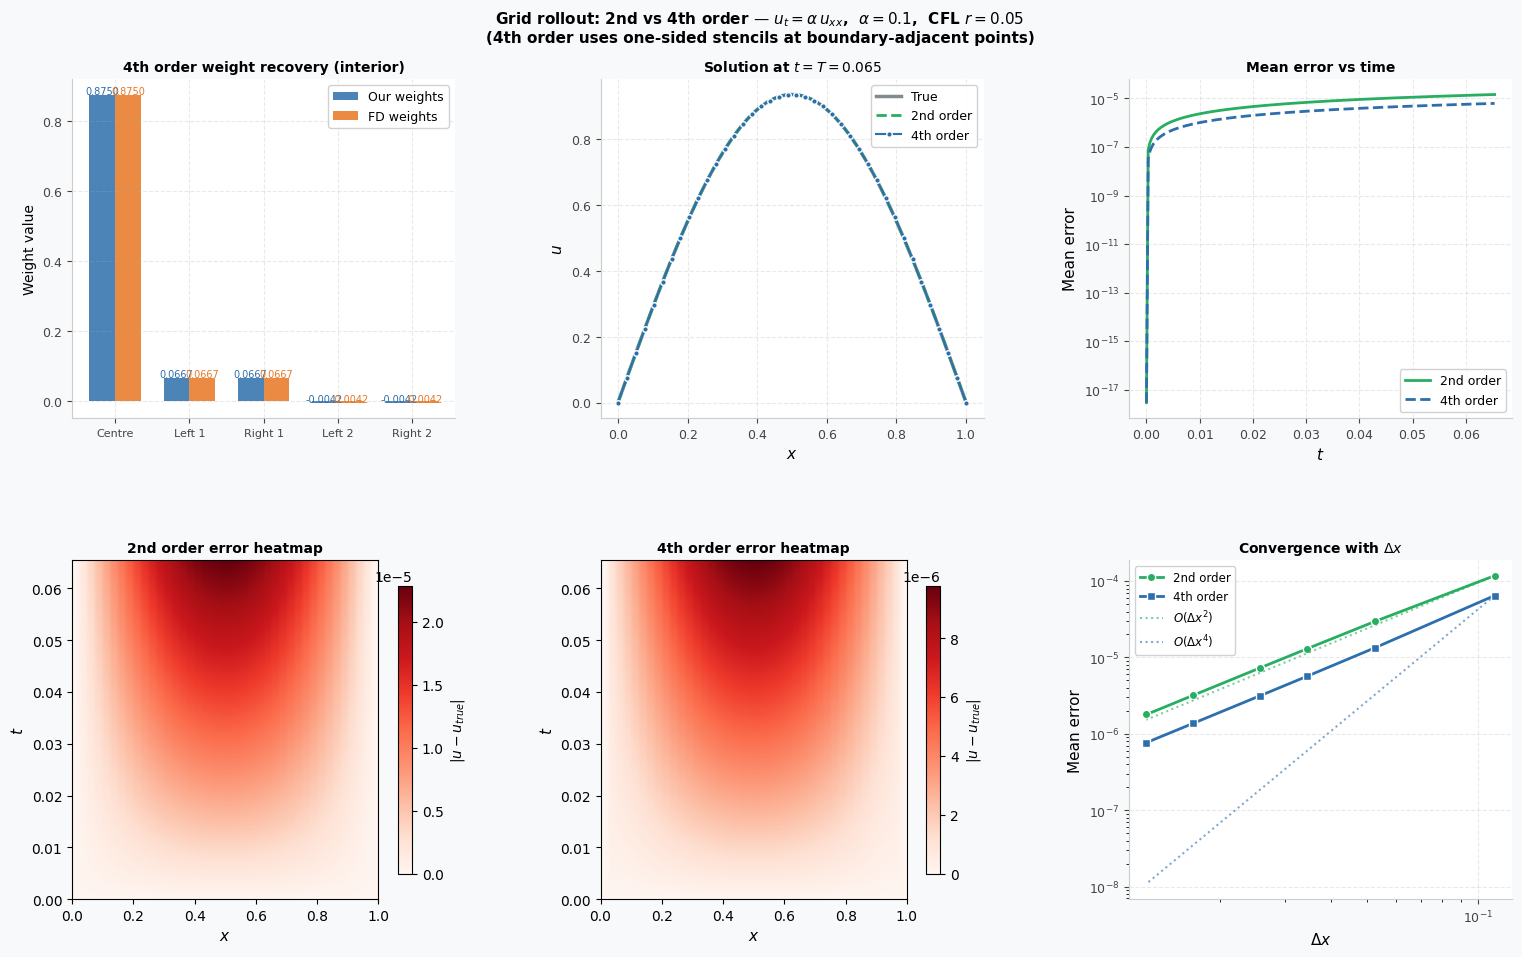

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha = 0.1
nx    = 40
nt    = 200
x     = np.linspace(0, 1, nx)
dx    = x[1] - x[0]

r     = 0.05
dt    = r * dx**2 / alpha
t     = np.linspace(0, dt * (nt - 1), nt)
T     = t[-1]

print(f"dx = {dx:.6f},  dt = {dt:.8f},  CFL r = {alpha*dt/dx**2:.4f},  T = {T:.4f}")

# ─────────────────────────────────────────────
# True solution
# ─────────────────────────────────────────────
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# ─────────────────────────────────────────────
# Weight solvers
# ─────────────────────────────────────────────
def solve_weights(dx_nb, dt_nb, alpha, order):
    """General weight solver given neighbour offsets and order (2 or 4)."""
    n = len(dx_nb)
    if order == 2:
        A = np.array([
            np.ones(n),
            dx_nb,
            0.5 * dx_nb**2 + alpha * dt_nb,
        ])
        b = np.array([1.0, 0.0, 0.0])
    else:  # order == 4
        A = np.array([
            np.ones(n),
            dx_nb,
            0.5 * dx_nb**2 + alpha * dt_nb,
            dx_nb**3 / 6,
            dx_nb**4 / 24,
        ])
        b = np.array([1.0, 0.0, 0.0, 0.0, 0.0])
    return np.linalg.solve(A, b)

def weights_2nd_order(dx, dt, alpha):
    """3 neighbours, 3 constraints — symmetric 2nd order"""
    dx_nb = np.array([0.0, -dx, +dx])
    dt_nb = np.array([-dt, -dt, -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=2)

def weights_4th_order(dx, dt, alpha):
    """5 neighbours, 5 constraints — symmetric 4th order (interior)"""
    dx_nb = np.array([0.0, -dx, +dx, -2*dx, +2*dx])
    dt_nb = np.array([-dt, -dt,  -dt,  -dt,   -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

def weights_4th_order_left(dx, dt, alpha):
    """5 neighbours — one-sided 4th order for j=1 (near left boundary).
    Neighbours: j-1, j, j+1, j+2, j+3  (offsets: -dx, 0, +dx, +2dx, +3dx)"""
    dx_nb = np.array([-dx,  0.0, +dx, +2*dx, +3*dx])
    dt_nb = np.array([-dt,  -dt, -dt,   -dt,   -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

def weights_4th_order_right(dx, dt, alpha):
    """5 neighbours — one-sided 4th order for j=nx-2 (near right boundary).
    Neighbours: j-3, j-2, j-1, j, j+1  (offsets: -3dx, -2dx, -dx, 0, +dx)"""
    dx_nb = np.array([-3*dx, -2*dx, -dx, 0.0, +dx])
    dt_nb = np.array([  -dt,   -dt, -dt, -dt,  -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

# compute weights once (same for all points at fixed dx, dt)
w2     = weights_2nd_order(dx, dt, alpha)
w4     = weights_4th_order(dx, dt, alpha)
w4_L   = weights_4th_order_left(dx, dt, alpha)
w4_R   = weights_4th_order_right(dx, dt, alpha)

# theoretical FD weights
w2_fd = np.array([1 - 2*r, r, r])
w4_fd = np.array([1 - 5*r/2, 4*r/3, 4*r/3, -r/12, -r/12])

print(f"\n─── 2nd order weight check ─────────────────────────────────")
print(f"Our:  {w2}")
print(f"FD:   {w2_fd}")
print(f"Diff: {w2 - w2_fd}")

print(f"\n─── 4th order weight check (interior) ──────────────────────")
print(f"Our:  {w4}")
print(f"FD:   {w4_fd}")
print(f"Diff: {w4 - w4_fd}")

print(f"\n─── 4th order one-sided weights ────────────────────────────")
print(f"Left  (j=1,   offsets -1,0,+1,+2,+3): {w4_L}")
print(f"Right (j=N-2, offsets -3,-2,-1,0,+1): {w4_R}")
print(f"Are they mirrors? {np.allclose(w4_L, w4_R[::-1])}")

# ─────────────────────────────────────────────
# Full rollout
# ─────────────────────────────────────────────
# 2nd order — symmetric stencil everywhere interior
U_2nd = np.zeros((nt, nx))
U_2nd[0, :] = u_true(x, 0)
U_2nd[:, 0] = 0.0
U_2nd[:,-1] = 0.0
for k in range(nt - 1):
    for j in range(1, nx - 1):
        u_nb = np.array([U_2nd[k,j], U_2nd[k,j-1], U_2nd[k,j+1]])
        U_2nd[k+1, j] = w2 @ u_nb

# 4th order — one-sided at j=1 and j=nx-2, symmetric elsewhere
U_4th = np.zeros((nt, nx))
U_4th[0, :] = u_true(x, 0)
U_4th[:, 0] = 0.0
U_4th[:,-1] = 0.0
for k in range(nt - 1):
    # j=1: one-sided right (uses j=0,1,2,3,4)
    j = 1
    u_nb = np.array([U_4th[k,j-1], U_4th[k,j], U_4th[k,j+1],
                     U_4th[k,j+2], U_4th[k,j+3]])
    U_4th[k+1, j] = w4_L @ u_nb

    # j=nx-2: one-sided left (uses j=nx-5,nx-4,nx-3,nx-2,nx-1)
    j = nx - 2
    u_nb = np.array([U_4th[k,j-3], U_4th[k,j-2], U_4th[k,j-1],
                     U_4th[k,j],   U_4th[k,j+1]])
    U_4th[k+1, j] = w4_R @ u_nb

    # interior — symmetric 4th order
    for j in range(2, nx - 2):
        u_nb = np.array([U_4th[k,j],   U_4th[k,j-1], U_4th[k,j+1],
                         U_4th[k,j-2], U_4th[k,j+2]])
        U_4th[k+1, j] = w4 @ u_nb

# ─────────────────────────────────────────────
# Errors vs true solution
# ─────────────────────────────────────────────
XX, TT = np.meshgrid(x, t)
U_ref  = u_true(XX, TT)

err_2nd = np.abs(U_2nd - U_ref)
err_4th = np.abs(U_4th - U_ref)

print(f"\n─── Full rollout errors vs true solution ───────────────────")
print(f"2nd order — mean: {err_2nd.mean():.4e}  max: {err_2nd.max():.4e}")
print(f"4th order — mean: {err_4th.mean():.4e}  max: {err_4th.max():.4e}")

# ─────────────────────────────────────────────
# Convergence study helper
# ─────────────────────────────────────────────
def run_convergence(nx_list, r, alpha, T):
    dx_list, err2_list, err4_list = [], [], []
    for nx_c in nx_list:
        x_c  = np.linspace(0, 1, nx_c)
        dx_c = x_c[1] - x_c[0]
        dt_c = r * dx_c**2 / alpha
        nt_c = max(10, int(T / dt_c) + 1)
        t_c  = np.arange(nt_c) * dt_c

        w2_c   = weights_2nd_order(dx_c, dt_c, alpha)
        w4_c   = weights_4th_order(dx_c, dt_c, alpha)
        w4_L_c = weights_4th_order_left(dx_c, dt_c, alpha)
        w4_R_c = weights_4th_order_right(dx_c, dt_c, alpha)

        U2 = np.zeros((nt_c, nx_c)); U2[0,:] = u_true(x_c, 0)
        U4 = np.zeros((nt_c, nx_c)); U4[0,:] = u_true(x_c, 0)

        for k in range(nt_c - 1):
            for j in range(1, nx_c-1):
                U2[k+1,j] = w2_c @ np.array([U2[k,j], U2[k,j-1], U2[k,j+1]])

            j = 1
            U4[k+1,j] = w4_L_c @ np.array([U4[k,j-1], U4[k,j],   U4[k,j+1],
                                             U4[k,j+2], U4[k,j+3]])
            j = nx_c - 2
            U4[k+1,j] = w4_R_c @ np.array([U4[k,j-3], U4[k,j-2], U4[k,j-1],
                                             U4[k,j],   U4[k,j+1]])
            for j in range(2, nx_c-2):
                U4[k+1,j] = w4_c @ np.array([U4[k,j],   U4[k,j-1], U4[k,j+1],
                                              U4[k,j-2], U4[k,j+2]])

        XX_c, TT_c = np.meshgrid(x_c, t_c)
        err2_list.append(np.abs(U2 - u_true(XX_c, TT_c)).mean())
        err4_list.append(np.abs(U4 - u_true(XX_c, TT_c)).mean())
        dx_list.append(dx_c)

    return np.array(dx_list), np.array(err2_list), np.array(err4_list)

dx_arr, err2_arr, err4_arr = run_convergence([10,20,30,40,60,80], r, alpha, T)

# print slopes
slopes2 = np.diff(np.log(err2_arr)) / np.diff(np.log(dx_arr))
slopes4 = np.diff(np.log(err4_arr)) / np.diff(np.log(dx_arr))
print(f"\n─── Convergence slopes ─────────────────────────────────────")
print(f"2nd order slopes: {slopes2.round(2)}")
print(f"4th order slopes: {slopes4.round(2)}")

# ─────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────
BLUE   = '#2C6FAC'
GREEN  = '#27AE60'
ORANGE = '#E87722'
GREY   = '#7F8C8D'

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.25, linestyle='--', color='#AAAAAA')

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38,
                        left=0.07, right=0.97, top=0.90, bottom=0.08)

# ── Panel 1: Weight comparison bar chart ─────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
labels4 = ['Centre', 'Left 1', 'Right 1', 'Left 2', 'Right 2']
xpos    = np.arange(5)
width   = 0.35
ax1.bar(xpos - width/2, w4,    width, color=BLUE,   label='Our weights', alpha=0.85)
ax1.bar(xpos + width/2, w4_fd, width, color=ORANGE, label='FD weights',  alpha=0.85)
ax1.set_xticks(xpos); ax1.set_xticklabels(labels4, fontsize=8)
ax1.set_ylabel('Weight value', fontsize=10)
ax1.set_title('4th order weight recovery (interior)', fontsize=10, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')
for i, (wo, wf) in enumerate(zip(w4, w4_fd)):
    ax1.text(i - width/2, wo + 0.002, f'{wo:.4f}', ha='center', fontsize=7, color=BLUE)
    ax1.text(i + width/2, wf + 0.002, f'{wf:.4f}', ha='center', fontsize=7, color=ORANGE)

# ── Panel 2: Solution at final time ──────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)
ax2.plot(x, u_true(x, T),  '-',  color=GREY,  linewidth=2.5, label='True', zorder=3)
ax2.plot(x, U_2nd[-1, :],  '--', color=GREEN,  linewidth=2,   label='2nd order', zorder=4)
ax2.plot(x, U_4th[-1, :],  'o-', color=BLUE,   linewidth=1.5, markersize=4,
         label='4th order', zorder=5, markeredgecolor='white')
ax2.set_xlabel('$x$', fontsize=11)
ax2.set_ylabel('$u$', fontsize=11)
ax2.set_title(f'Solution at $t = T = {T:.3f}$', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

# ── Panel 3: Mean error vs time ───────────────
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)
ax3.semilogy(t, err_2nd.mean(axis=1), '-',  color=GREEN, linewidth=2, label='2nd order')
ax3.semilogy(t, err_4th.mean(axis=1), '--', color=BLUE,  linewidth=2, label='4th order')
ax3.set_xlabel('$t$', fontsize=11)
ax3.set_ylabel('Mean error', fontsize=11)
ax3.set_title('Mean error vs time', fontsize=10, fontweight='bold')
ax3.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

# ── Panel 4: 2nd order error heatmap ─────────
ax4 = fig.add_subplot(gs[1, 0])
im4 = ax4.imshow(err_2nd, origin='lower', aspect='auto',
                 extent=[0, 1, 0, T], cmap='Reds')
plt.colorbar(im4, ax=ax4, label='$|u - u_{true}|$', shrink=0.85)
ax4.set_xlabel('$x$', fontsize=11); ax4.set_ylabel('$t$', fontsize=11)
ax4.set_title('2nd order error heatmap', fontsize=10, fontweight='bold')

# ── Panel 5: 4th order error heatmap ─────────
ax5 = fig.add_subplot(gs[1, 1])
im5 = ax5.imshow(err_4th, origin='lower', aspect='auto',
                 extent=[0, 1, 0, T], cmap='Reds')
plt.colorbar(im5, ax=ax5, label='$|u - u_{true}|$', shrink=0.85)
ax5.set_xlabel('$x$', fontsize=11); ax5.set_ylabel('$t$', fontsize=11)
ax5.set_title('4th order error heatmap', fontsize=10, fontweight='bold')

# ── Panel 6: Convergence with dx ─────────────
ax6 = fig.add_subplot(gs[1, 2])
style_ax(ax6)

ax6.loglog(dx_arr, err2_arr, 'o-', color=GREEN, linewidth=2, markersize=6,
           markeredgecolor='white', label='2nd order')
ax6.loglog(dx_arr, err4_arr, 's-', color=BLUE,  linewidth=2, markersize=6,
           markeredgecolor='white', label='4th order')

ref2 = err2_arr[0] / dx_arr[0]**2 * dx_arr**2
ref4 = err4_arr[0] / dx_arr[0]**4 * dx_arr**4
ax6.loglog(dx_arr, ref2, ':', color=GREEN, alpha=0.6, label='$O(\\Delta x^2)$')
ax6.loglog(dx_arr, ref4, ':', color=BLUE,  alpha=0.6, label='$O(\\Delta x^4)$')

ax6.set_xlabel('$\\Delta x$', fontsize=11)
ax6.set_ylabel('Mean error', fontsize=11)
ax6.set_title('Convergence with $\\Delta x$', fontsize=10, fontweight='bold')
ax6.legend(fontsize=8.5, framealpha=0.9, edgecolor='#CCCCCC')

fig.suptitle(
    r'Grid rollout: 2nd vs 4th order — $u_t = \alpha\,u_{xx}$,  $\alpha=0.1$,  CFL $r=0.05$'
    '\n(4th order uses one-sided stencils at boundary-adjacent points)',
    fontsize=11, fontweight='bold', y=0.97
)


Convergence slopes: [2.13 2.   2.01 1.99 1.99]

Bound verification (error < Taylor bound < ?):
  nx= 10  err=6.466e-05  4th_bound=1.686e-01  taylor_bound=4.955e-01  err<4th? True  err<taylor? True
  nx= 20  err=1.312e-05  4th_bound=4.021e-03  taylor_bound=1.112e-01  err<4th? True  err<taylor? True
  nx= 30  err=5.626e-06  4th_bound=4.854e-04  taylor_bound=4.772e-02  err<4th? True  err<taylor? True
  nx= 40  err=3.105e-06  4th_bound=1.103e-04  taylor_bound=2.639e-02  err<4th? True  err<taylor? True
  nx= 60  err=1.365e-06  4th_bound=1.393e-05  taylor_bound=1.153e-02  err<4th? True  err<taylor? True
  nx= 80  err=7.641e-07  4th_bound=3.236e-06  taylor_bound=6.431e-03  err<4th? True  err<taylor? True

Saved: convergence_bounds.png


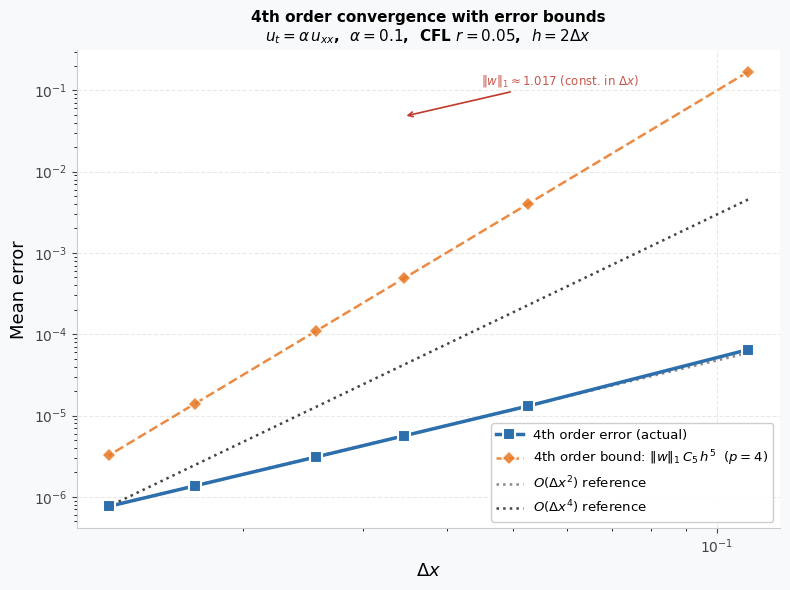

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha = 0.1
r     = 0.05
T     = 0.065

def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# ─────────────────────────────────────────────
# Weight solvers
# ─────────────────────────────────────────────
def solve_weights_4th(dx_nb, dt_nb, alpha):
    A = np.array([
        np.ones(5),
        dx_nb,
        0.5 * dx_nb**2 + alpha * dt_nb,
        dx_nb**3 / 6,
        dx_nb**4 / 24,
    ])
    return np.linalg.solve(A, np.array([1., 0, 0, 0, 0]))

def get_all_weights(dx, dt, alpha):
    w4   = solve_weights_4th(np.array([ 0.,-1,+1,-2,+2])*dx, np.full(5,-dt), alpha)
    w4_L = solve_weights_4th(np.array([-1, 0,+1,+2,+3])*dx,  np.full(5,-dt), alpha)
    w4_R = solve_weights_4th(np.array([-3,-2,-1, 0,+1])*dx,  np.full(5,-dt), alpha)
    return w4, w4_L, w4_R

# ─────────────────────────────────────────────
# Error bound components
# u(x,t) = exp(-alpha*pi^2*t) * sin(pi*x)
#
# Taylor bound (paper, pure Taylor, p=1):
#   |e| <= ||w||_1 * C2 * h^2
#   C2 = max|uxx| = pi^2 * exp(-alpha*pi^2*t)   [conservative: use t~0]
#
# 4th order bound (p=4, first discarded term is order 5):
#   |e| <= ||w||_1 * C5 * h^5
#   C5 = max|d^5u/dx^5| = pi^5 * exp(-alpha*pi^2*t)  [conservative: use t~0]
#
# h = max neighbour distance = 2*dx for the symmetric 5-point stencil
# ─────────────────────────────────────────────
def C2(alpha, T):
    """Conservative upper bound on 2nd order derivatives over [0,T]."""
    return np.pi**2  # exp(-alpha*pi^2*t) <= 1 at t=0

def C5(alpha, T):
    """Conservative upper bound on 5th order derivatives over [0,T]."""
    return np.pi**5  # same reasoning

# ─────────────────────────────────────────────
# Convergence study
# ─────────────────────────────────────────────
nx_list = [10, 20, 30, 40, 60, 80]
dx_vals, err_vals, bound_taylor_vals, bound_4th_vals = [], [], [], []

for nx_c in nx_list:
    x_c  = np.linspace(0, 1, nx_c)
    dx_c = x_c[1] - x_c[0]
    dt_c = r * dx_c**2 / alpha
    nt_c = max(10, int(T / dt_c) + 1)

    w4, w4_L, w4_R = get_all_weights(dx_c, dt_c, alpha)

    U4 = np.zeros((nt_c, nx_c))
    U4[0, :] = u_true(x_c, 0)

    for k in range(nt_c - 1):
        j = 1
        U4[k+1, j] = w4_L @ [U4[k,j-1], U4[k,j],   U4[k,j+1],
                               U4[k,j+2], U4[k,j+3]]
        j = nx_c - 2
        U4[k+1, j] = w4_R @ [U4[k,j-3], U4[k,j-2], U4[k,j-1],
                               U4[k,j],   U4[k,j+1]]
        for j in range(2, nx_c - 2):
            U4[k+1, j] = w4 @ [U4[k,j],   U4[k,j-1], U4[k,j+1],
                                U4[k,j-2], U4[k,j+2]]

    XX_c, TT_c = np.meshgrid(x_c, np.arange(nt_c) * dt_c)
    mean_err = np.abs(U4 - u_true(XX_c, TT_c)).mean()

    h = 2 * dx_c                          # max neighbour distance
    w1 = np.sum(np.abs(w4))              # ||w||_1 of interior stencil

    dx_vals.append(dx_c)
    err_vals.append(mean_err)
    bound_taylor_vals.append(w1 * C2(alpha, T) * h**2)
    bound_4th_vals.append(w1 * C5(alpha, T) * h**5)

dx_arr        = np.array(dx_vals)
err_arr       = np.array(err_vals)
bound_taylor  = np.array(bound_taylor_vals)
bound_4th     = np.array(bound_4th_vals)

# Print slopes
slopes = np.diff(np.log(err_arr)) / np.diff(np.log(dx_arr))
print("Convergence slopes:", slopes.round(2))
print("\nBound verification (error < Taylor bound < ?):")
for i, nx_c in enumerate(nx_list):
    print(f"  nx={nx_c:3d}  err={err_arr[i]:.3e}  "
          f"4th_bound={bound_4th[i]:.3e}  "
          f"taylor_bound={bound_taylor[i]:.3e}  "
          f"err<4th? {err_arr[i] < bound_4th[i]}  "
          f"err<taylor? {err_arr[i] < bound_taylor[i]}")

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
BLUE   = '#2C6FAC'
GREEN  = '#27AE60'
AMBER  = '#E87722'
RED    = '#C0392B'

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('white')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.tick_params(colors='#444444', labelsize=10)
ax.grid(True, alpha=0.25, linestyle='--', color='#AAAAAA')

# Actual error
ax.loglog(dx_arr, err_arr, 's-', color=BLUE, linewidth=2.5, markersize=8,
          markeredgecolor='white', markeredgewidth=1.5,
          label='4th order error (actual)', zorder=5)
 
# 4th order bound: ||w||_1 * C5 * h^5
ax.loglog(dx_arr, bound_4th, 'D--', color=AMBER, linewidth=1.8, markersize=7,
          markeredgecolor='white', markeredgewidth=1.2, alpha=0.85,
          label=r'4th order bound: $\|w\|_1\,C_5\,h^5$  ($p{=}4$)', zorder=4)

# Reference slopes — anchor at smallest dx so lines sit visibly above/through data
# O(dx^2): anchored at last point → runs parallel to actual error (slope ~2)
# O(dx^4): anchored at last point → diverges upward left, showing what slope 4 would look like
ref2 = err_arr[-1] / dx_arr[-1]**2 * dx_arr**2
ref4 = err_arr[-1] / dx_arr[-1]**4 * dx_arr**4
ax.loglog(dx_arr, ref2, ':', color='#888888', linewidth=1.8,
          label=r'$O(\Delta x^2)$ reference')
ax.loglog(dx_arr, ref4, ':', color='#444444', linewidth=1.8,
          label=r'$O(\Delta x^4)$ reference')

ax.set_xlabel(r'$\Delta x$', fontsize=13)
ax.set_ylabel('Mean error', fontsize=13)
ax.set_title(
    r'4th order convergence with error bounds' '\n'
    r'$u_t = \alpha\,u_{xx}$,  $\alpha=0.1$,  CFL $r=0.05$,  $h = 2\Delta x$',
    fontsize=11, fontweight='bold'
)

# Annotate what each bound is
ax.annotate(
    r'$\|w\|_1 \approx 1.017$ (const. in $\Delta x$)',
    xy=(dx_arr[2], bound_taylor[2]),
    xytext=(dx_arr[2]*1.3, bound_taylor[2]*2.5),
    fontsize=8.5, color=RED, alpha=0.85,
    arrowprops=dict(arrowstyle='->', color=RED, lw=1.2)
)

ax.legend(fontsize=9.5, framealpha=0.95, edgecolor='#CCCCCC',
          loc='lower right')

plt.tight_layout()
plt.savefig('convergence_bounds.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print("\nSaved: convergence_bounds.png")

   nx        dx          dt       nt    mean_err   slope   ||w||_1   4th_bound  taylor_bound
   10   0.11111   7.621e-04       86  7.6049e-04     nan    1.0021   1.662e-01     4.884e-01
   15   0.07143   1.302e-04      500  1.3575e-04    3.90    1.0009   1.822e-02     2.016e-01
   20   0.05263   3.837e-05     1695  4.1020e-05    3.92    1.0005   3.957e-03     1.094e-01
   30   0.03448   7.069e-06     9195  7.7669e-06    3.94    1.0002   4.775e-04     4.695e-02
   40   0.02564   2.161e-06    30075  2.4092e-06    3.95    1.0001   1.085e-04     2.596e-02
   55   0.01852   5.880e-07   110540  6.6357e-07    3.96    1.0001   2.133e-05     1.354e-02

Bound verification (all must be True):
  err < 4th_bound:    True
  err < taylor_bound: True

Saved: convergence_bounds_4th.png


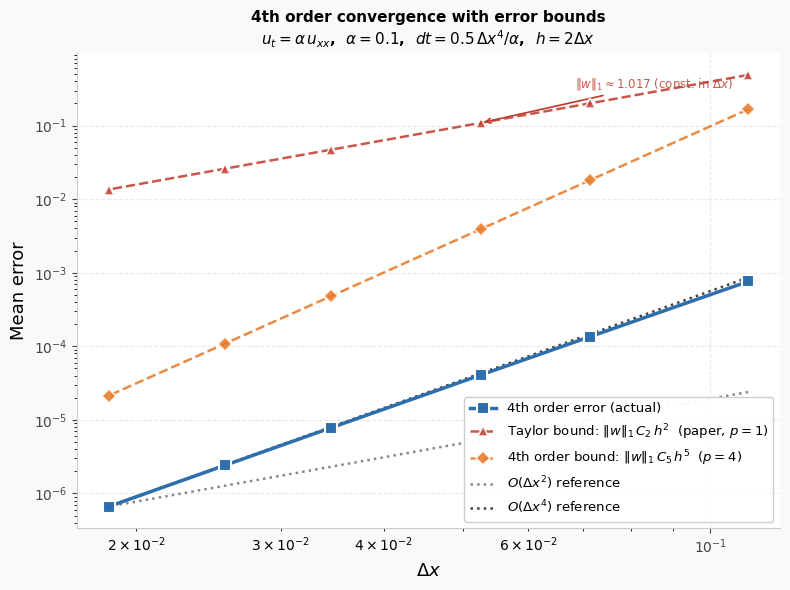

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha = 0.1
C_dt  = 0.5   # dt = C_dt * dx^4 / alpha  →  temporal error O(dx^4)
T     = 0.065

def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# ─────────────────────────────────────────────
# Weight solvers
# ─────────────────────────────────────────────
def solve_weights_4th(dx_nb, dt_nb, alpha):
    A = np.array([
        np.ones(5),
        dx_nb,
        0.5 * dx_nb**2 + alpha * dt_nb,
        dx_nb**3 / 6,
        dx_nb**4 / 24,
    ])
    return np.linalg.solve(A, np.array([1., 0, 0, 0, 0]))

def get_all_weights(dx, dt, alpha):
    w4   = solve_weights_4th(np.array([ 0.,-1,+1,-2,+2])*dx, np.full(5,-dt), alpha)
    w4_L = solve_weights_4th(np.array([-1, 0,+1,+2,+3])*dx,  np.full(5,-dt), alpha)
    w4_R = solve_weights_4th(np.array([-3,-2,-1, 0,+1])*dx,  np.full(5,-dt), alpha)
    return w4, w4_L, w4_R

# ─────────────────────────────────────────────
# Error bound constants
# u = exp(-alpha*pi^2*t)*sin(pi*x)
# C2: max 2nd order derivative  = pi^2   (conservative, t=0)
# C5: max 5th order derivative  = pi^5   (conservative, t=0)
# h  = 2*dx  (max neighbour distance for 5-point stencil)
# ─────────────────────────────────────────────
C2 = np.pi**2
C5 = np.pi**5

# ─────────────────────────────────────────────
# Rollout (vectorised, memory-efficient: keep only 2 time rows)
# ─────────────────────────────────────────────
def run(nx_c):
    x_c  = np.linspace(0, 1, nx_c)
    dx_c = x_c[1] - x_c[0]
    dt_c = C_dt * dx_c**4 / alpha
    nt_c = int(T / dt_c) + 1

    w4, w4_L, w4_R = get_all_weights(dx_c, dt_c, alpha)

    U = np.zeros((2, nx_c))
    U[0] = u_true(x_c, 0)

    for k in range(nt_c - 1):
        cur = U[k % 2]
        nxt = U[(k + 1) % 2]
        nxt[0]  = 0.
        nxt[-1] = 0.

        # left boundary-adjacent: one-sided right
        nxt[1] = w4_L @ [cur[0], cur[1], cur[2], cur[3], cur[4]]

        # right boundary-adjacent: one-sided left
        j = nx_c - 2
        nxt[j] = w4_R @ [cur[j-3], cur[j-2], cur[j-1], cur[j], cur[j+1]]

        # interior: symmetric 4th order (vectorised)
        j = np.arange(2, nx_c - 2)
        nxt[j] = (w4[0] * cur[j]
                + w4[1] * cur[j-1] + w4[2] * cur[j+1]
                + w4[3] * cur[j-2] + w4[4] * cur[j+2])

    t_final = nt_c * dt_c
    u_final = U[nt_c % 2]
    mean_err = np.abs(u_final - u_true(x_c, t_final)).mean()
    w1_norm  = np.sum(np.abs(w4))
    return mean_err, dx_c, dt_c, nt_c, w1_norm

# ─────────────────────────────────────────────
# Convergence study
# ─────────────────────────────────────────────
nx_list = [10, 15, 20, 30, 40, 55]

dx_vals, err_vals, bound_taylor_vals, bound_4th_vals = [], [], [], []

print(f"{'nx':>5} {'dx':>9} {'dt':>11} {'nt':>8} {'mean_err':>11} {'slope':>7} "
      f"{'||w||_1':>9} {'4th_bound':>11} {'taylor_bound':>13}")

prev_err, prev_dx = None, None
for nx_c in nx_list:
    mean_err, dx_c, dt_c, nt_c, w1 = run(nx_c)
    h = 2 * dx_c
    b_taylor = w1 * C2 * h**2
    b_4th    = w1 * C5 * h**5

    slope = (np.log(prev_err / mean_err) / np.log(prev_dx / dx_c)
             if prev_err else float('nan'))

    print(f"{nx_c:>5} {dx_c:>9.5f} {dt_c:>11.3e} {nt_c:>8} {mean_err:>11.4e} "
          f"{slope:>7.2f} {w1:>9.4f} {b_4th:>11.3e} {b_taylor:>13.3e}")

    dx_vals.append(dx_c)
    err_vals.append(mean_err)
    bound_taylor_vals.append(b_taylor)
    bound_4th_vals.append(b_4th)
    prev_err, prev_dx = mean_err, dx_c

dx_arr       = np.array(dx_vals)
err_arr      = np.array(err_vals)
bound_taylor = np.array(bound_taylor_vals)
bound_4th    = np.array(bound_4th_vals)

print(f"\nBound verification (all must be True):")
print(f"  err < 4th_bound:    {np.all(err_arr < bound_4th)}")
print(f"  err < taylor_bound: {np.all(err_arr < bound_taylor)}")

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
BLUE  = '#2C6FAC'
AMBER = '#E87722'
RED   = '#C0392B'

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('white')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.tick_params(colors='#444444', labelsize=10)
ax.grid(True, alpha=0.25, linestyle='--', color='#AAAAAA')

# Actual error
ax.loglog(dx_arr, err_arr, 's-', color=BLUE, linewidth=2.5, markersize=8,
          markeredgecolor='white', markeredgewidth=1.5,
          label='4th order error (actual)', zorder=5)

# Taylor bound from paper
ax.loglog(dx_arr, bound_taylor, '^--', color=RED, linewidth=1.8, markersize=7,
          markeredgecolor='white', markeredgewidth=1.2, alpha=0.85,
          label=r'Taylor bound: $\|w\|_1\,C_2\,h^2$  (paper, $p{=}1$)', zorder=4)

# 4th order bound
ax.loglog(dx_arr, bound_4th, 'D--', color=AMBER, linewidth=1.8, markersize=7,
          markeredgecolor='white', markeredgewidth=1.2, alpha=0.85,
          label=r'4th order bound: $\|w\|_1\,C_5\,h^5$  ($p{=}4$)', zorder=4)

# Reference slopes — anchor at smallest dx so lines sit above data
ref2 = err_arr[-1] / dx_arr[-1]**2 * dx_arr**2
ref4 = err_arr[-1] / dx_arr[-1]**4 * dx_arr**4
ax.loglog(dx_arr, ref2, ':', color='#888888', linewidth=1.8,
          label=r'$O(\Delta x^2)$ reference')
ax.loglog(dx_arr, ref4, ':', color='#444444', linewidth=1.8,
          label=r'$O(\Delta x^4)$ reference')

# Annotate ||w||_1
ax.annotate(
    r'$\|w\|_1 \approx 1.017$ (const. in $\Delta x$)',
    xy=(dx_arr[2], bound_taylor[2]),
    xytext=(dx_arr[2] * 1.3, bound_taylor[2] * 3),
    fontsize=8.5, color=RED, alpha=0.85,
    arrowprops=dict(arrowstyle='->', color=RED, lw=1.2)
)

ax.set_xlabel(r'$\Delta x$', fontsize=13)
ax.set_ylabel('Mean error', fontsize=13)
ax.set_title(
    r'4th order convergence with error bounds' '\n'
    r'$u_t = \alpha\,u_{xx}$,  $\alpha=0.1$,  '
    r'$dt = 0.5\,\Delta x^4/\alpha$,  $h = 2\Delta x$',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9.5, framealpha=0.95, edgecolor='#CCCCCC', loc='lower right')

plt.tight_layout()
plt.savefig('convergence_bounds_4th.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print("\nSaved: convergence_bounds_4th.png")

Generating FD reference...
FD reference: nx=200, nt=496, T=0.0500

Scattered integrator: nx_sc=20, dt_strip=0.005, n_strips=11

Running scattered integrator...
Done. Points computed: 200,  skipped: 0,  BC added: 20
Mean error vs FD:  8.4223e-05
Max  error vs FD:  6.4270e-04
Mean ||w||_1:      1.1159
Mean cond(A):      1.46e+06


Text(0.5, 0.97, 'Scattered point integrator — $u_t = \\alpha\\,u_{xx}$,  $\\alpha=0.1$,  $T=0.05$,  random neighbour selection')

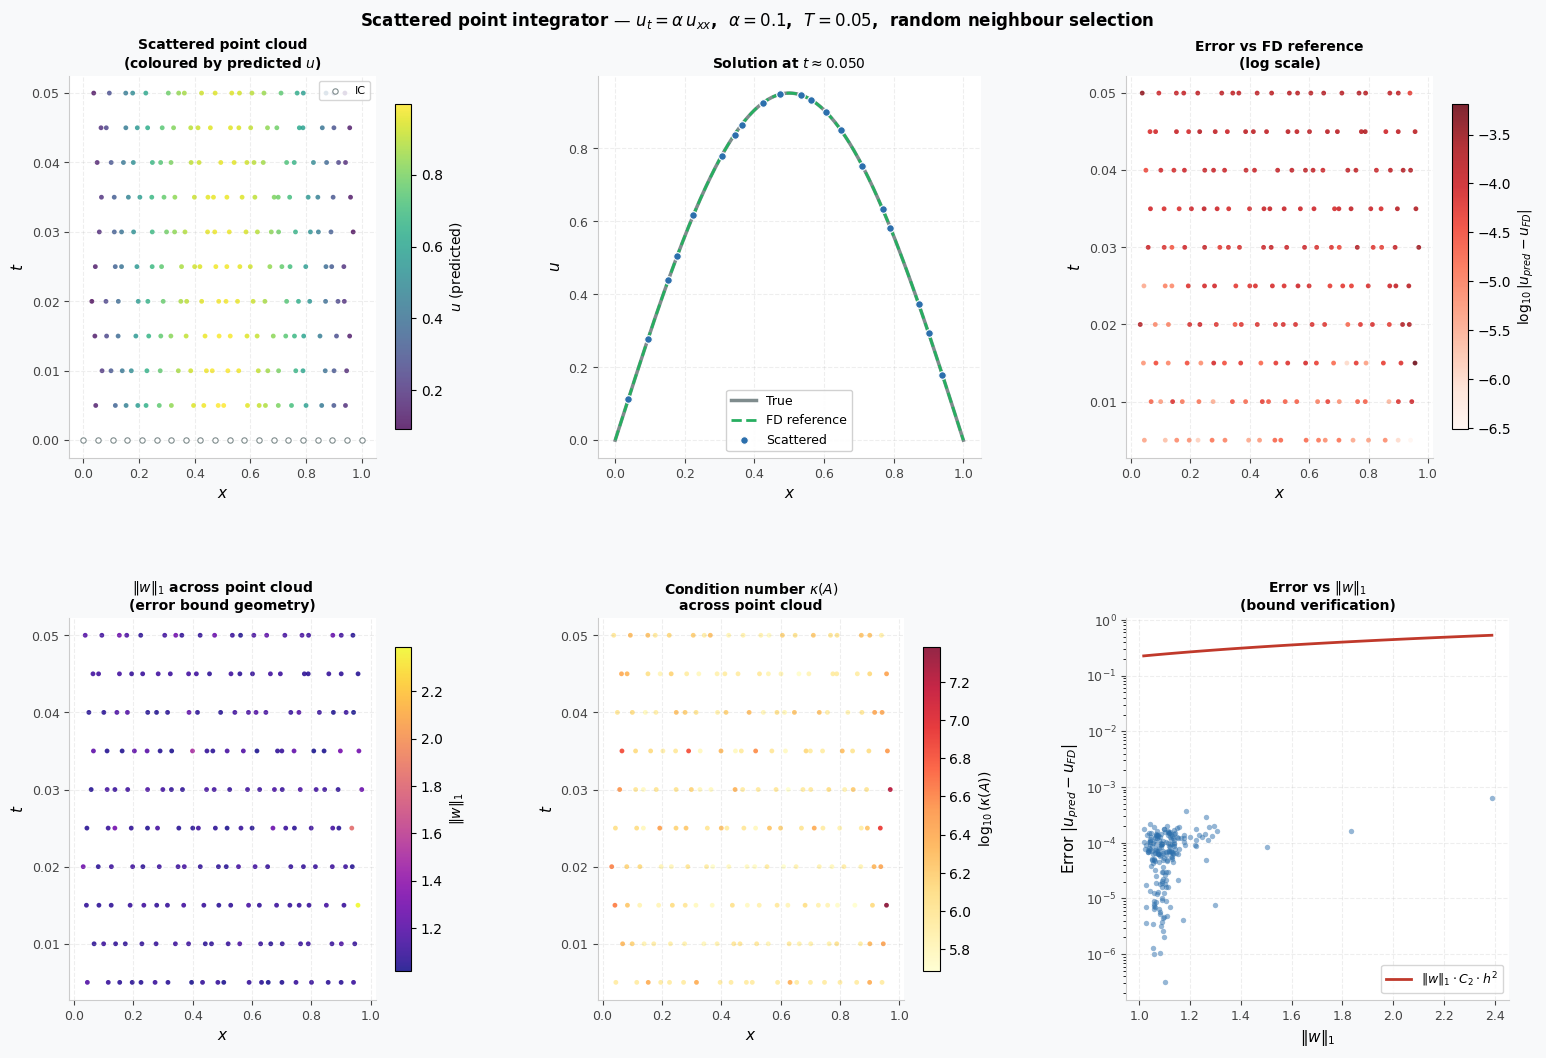

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from collections import defaultdict

np.random.seed(42)

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha  = 0.1
T      = 0.05

# ─────────────────────────────────────────────
# True solution & FD reference
# ─────────────────────────────────────────────
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

def generate_fd_reference(nx=200, r=0.4):
    """High-accuracy FD reference on fine uniform grid."""
    x   = np.linspace(0, 1, nx)
    dx  = x[1] - x[0]
    dt  = r * dx**2 / alpha
    nt  = int(T / dt) + 1
    lam = alpha * dt / dx**2

    U = np.zeros((nt, nx))
    U[0] = u_true(x, 0)
    for k in range(nt - 1):
        U[k+1, 1:-1] = (U[k, 1:-1]
                        + lam * (U[k, 2:] - 2*U[k, 1:-1] + U[k, :-2]))
        U[k+1, 0] = U[k+1, -1] = 0.0

    t = np.arange(nt) * dt
    return x, t, U

print("Generating FD reference...")
x_fd, t_fd, U_fd = generate_fd_reference(nx=200, r=0.4)
print(f"FD reference: nx={len(x_fd)}, nt={len(t_fd)}, T={t_fd[-1]:.4f}")

def fd_interp(x_q, t_q):
    """Bilinear interpolation into FD reference solution."""
    ix = np.searchsorted(x_fd, x_q, side='right') - 1
    it = np.searchsorted(t_fd, t_q, side='right') - 1
    ix = np.clip(ix, 0, len(x_fd) - 2)
    it = np.clip(it, 0, len(t_fd) - 2)
    tx = (x_q - x_fd[ix]) / (x_fd[ix+1] - x_fd[ix])
    tt = (t_q - t_fd[it]) / (t_fd[it+1] - t_fd[it])
    return ((1-tt)*(1-tx)*U_fd[it,   ix  ]
          + (1-tt)*   tx *U_fd[it,   ix+1]
          +    tt *(1-tx)*U_fd[it+1, ix  ]
          +    tt *   tx *U_fd[it+1, ix+1])

# ─────────────────────────────────────────────
# Scattered integrator parameters
# ─────────────────────────────────────────────
nx_sc        = 20          # number of x points per time strip
n_neighbours = 5           # neighbours per side (left/right in x)
n_min        = 5           # minimum total neighbours needed
box_x_init   = 0.15        # initial half-width of search box in x
box_t_init   = 0.01        # initial look-back window in t
box_x_max    = 0.5         # maximum box half-width in x
box_t_max    = T           # maximum look-back in t
box_growth   = 1.5         # expansion factor when not enough neighbours
cond_thresh  = 1e8         # reject stencil if cond(A) exceeds this

# Time strip spacing for scattered points
dt_sc   = 0.005            # spacing between time strips
t_strips = np.arange(0, T + dt_sc, dt_sc)
print(f"\nScattered integrator: nx_sc={nx_sc}, dt_strip={dt_sc}, "
      f"n_strips={len(t_strips)}")

# ─────────────────────────────────────────────
# Weight solver (pseudoinverse, any n neighbours)
# ─────────────────────────────────────────────
def solve_weights(dx_nb, dt_nb, alpha):
    """
    Build constraint matrix and solve via pseudoinverse.
    Constraints: consistency, kill ux, PDE row, kill uxxx, kill uxxxx.
    Returns weights and condition number.
    """
    n = len(dx_nb)
    A = np.array([
        np.ones(n),                          # consistency
        dx_nb,                               # kill ux
        0.5 * dx_nb**2 + alpha * dt_nb,      # PDE: ut = alpha*uxx
        dx_nb**3 / 6,                        # kill uxxx
        dx_nb**4 / 24,                       # kill uxxxx
    ])
    b = np.array([1., 0, 0, 0, 0])
    cond = np.linalg.cond(A)
    w = np.linalg.lstsq(A, b, rcond=None)[0]
    return w, cond

# ─────────────────────────────────────────────
# Neighbour search: expanding box, backward in time
# ─────────────────────────────────────────────
def find_neighbours(x_star, t_star, visited, n_min,
                    box_x0, box_t0, box_x_max, box_t_max, box_growth):
    """
    Expand box until n_min neighbours found (all at t < t_star).
    Returns list of (x, t, u) tuples or None if expansion fails.
    """
    box_x, box_t = box_x0, box_t0
    while True:
        neighbours = [
            pt for pt in visited
            if (abs(pt[0] - x_star) <= box_x
                and pt[1] < t_star
                and (t_star - pt[1]) <= box_t)
        ]
        if len(neighbours) >= n_min:
            return neighbours
        # expand
        box_x = min(box_x * box_growth, box_x_max)
        box_t = min(box_t * box_growth, box_t_max)
        if box_x >= box_x_max and box_t >= box_t_max:
            return None   # give up

# ─────────────────────────────────────────────
# Main integrator
# ─────────────────────────────────────────────

# visited: list of (x, t, u)
visited = []

# --- Initialise from IC (t=0) ---
x_ic = np.linspace(0, 1, nx_sc)
for xi in x_ic:
    visited.append((xi, 0.0, u_true(xi, 0.0)))

# --- BC points: added to visited lazily when box reaches x=0 or x=1 ---
# We pre-build a lookup: for any t, u(0,t)=0, u(1,t)=0
def bc_value(x, t):
    return 0.0

# Track results for plotting
result_points  = []   # (x, t, u_pred)
error_points   = []   # (x, t, |u_pred - u_ref|)
w1_norm_points = []   # (x, t, ||w||_1)
cond_points    = []   # (x, t, cond(A))
skipped        = 0
bc_added       = 0

print("\nRunning scattered integrator...")

for t_star in t_strips[1:]:   # skip t=0 (IC)
    # scatter nx_sc points randomly in x (interior only)
    # use slight jitter around uniform to avoid degeneracy
    x_candidates = np.linspace(0.05, 0.95, nx_sc) + \
                   np.random.uniform(-0.02, 0.02, nx_sc)
    x_candidates = np.clip(x_candidates, 0.02, 0.98)
    np.random.shuffle(x_candidates)

    # Add BC points to visited for this time level lazily
    for x_bc in [0.0, 1.0]:
        visited.append((x_bc, t_star, bc_value(x_bc, t_star)))
        bc_added += 1

    for x_star in x_candidates:
        # find neighbours (backward in time only)
        neighbours = find_neighbours(
            x_star, t_star, visited, n_min,
            box_x_init, box_t_init, box_x_max, box_t_max, box_growth
        )
        if neighbours is None:
            skipped += 1
            continue

        # build offset arrays
        nb_arr = np.array(neighbours)
        dx_nb  = nb_arr[:, 0] - x_star
        dt_nb  = nb_arr[:, 1] - t_star
        u_nb   = nb_arr[:, 2]

        # solve weights
        w, cond = solve_weights(dx_nb, dt_nb, alpha)
        if cond > cond_thresh:
            skipped += 1
            continue

        u_pred = w @ u_nb

        # mark as visited
        visited.append((x_star, t_star, u_pred))

        # store diagnostics
        u_ref  = fd_interp(x_star, t_star)
        result_points.append((x_star, t_star, u_pred))
        error_points.append((x_star, t_star, abs(u_pred - u_ref)))
        w1_norm_points.append((x_star, t_star, np.sum(np.abs(w))))
        cond_points.append((x_star, t_star, cond))

result_arr  = np.array(result_points)
error_arr   = np.array(error_points)
w1_arr      = np.array(w1_norm_points)
cond_arr    = np.array(cond_points)

print(f"Done. Points computed: {len(result_arr)},  skipped: {skipped},  BC added: {bc_added}")
print(f"Mean error vs FD:  {error_arr[:,2].mean():.4e}")
print(f"Max  error vs FD:  {error_arr[:,2].max():.4e}")
print(f"Mean ||w||_1:      {w1_arr[:,2].mean():.4f}")
print(f"Mean cond(A):      {cond_arr[:,2].mean():.2e}")

# ─────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────
BLUE  = '#2C6FAC'
GREEN = '#27AE60'
RED   = '#C0392B'
AMBER = '#E87722'
GREY  = '#7F8C8D'

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.2, linestyle='--', color='#AAAAAA')

fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38,
                        left=0.07, right=0.97, top=0.91, bottom=0.07)

# ── Panel 1: Point cloud in (x,t) plane ──────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
sc = ax1.scatter(result_arr[:,0], result_arr[:,1],
                 c=result_arr[:,2], cmap='viridis',
                 s=12, alpha=0.8, linewidths=0)
plt.colorbar(sc, ax=ax1, label='$u$ (predicted)', shrink=0.85)
# overlay IC
ic_arr = np.array([(xi, 0.0) for xi in x_ic])
ax1.scatter(ic_arr[:,0], ic_arr[:,1], c='white', s=15,
            edgecolors=GREY, linewidths=0.8, zorder=5, label='IC')
ax1.set_xlabel('$x$', fontsize=11); ax1.set_ylabel('$t$', fontsize=11)
ax1.set_title('Scattered point cloud\n(coloured by predicted $u$)',
              fontsize=10, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')

# ── Panel 2: Solution at final time strip ─────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)
# get points near final time strip
t_final_strip = t_strips[-1]
mask = np.abs(result_arr[:,1] - t_final_strip) < dt_sc * 0.6
x_plot = result_arr[mask, 0]
u_plot = result_arr[mask, 2]
idx    = np.argsort(x_plot)
x_fine = np.linspace(0, 1, 300)
ax2.plot(x_fine, u_true(x_fine, t_final_strip), '-',
         color=GREY, linewidth=2.5, label='True', zorder=3)
ax2.plot(x_fine, [fd_interp(xi, t_final_strip) for xi in x_fine], '--',
         color=GREEN, linewidth=2, label='FD reference', zorder=4)
ax2.scatter(x_plot[idx], u_plot[idx], color=BLUE, s=30, zorder=5,
            edgecolors='white', linewidths=0.8, label='Scattered')
ax2.set_xlabel('$x$', fontsize=11); ax2.set_ylabel('$u$', fontsize=11)
ax2.set_title(f'Solution at $t \\approx {t_final_strip:.3f}$',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=9, framealpha=0.9)

# ── Panel 3: Error vs true solution ──────────
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)
sc3 = ax3.scatter(error_arr[:,0], error_arr[:,1],
                  c=np.log10(error_arr[:,2] + 1e-16),
                  cmap='Reds', s=12, alpha=0.85, linewidths=0)
cb3 = plt.colorbar(sc3, ax=ax3, shrink=0.85)
cb3.set_label('$\\log_{10}|u_{pred} - u_{FD}|$')
ax3.set_xlabel('$x$', fontsize=11); ax3.set_ylabel('$t$', fontsize=11)
ax3.set_title('Error vs FD reference\n(log scale)',
              fontsize=10, fontweight='bold')

# ── Panel 4: ||w||_1 distribution ────────────
ax4 = fig.add_subplot(gs[1, 0])
style_ax(ax4)
sc4 = ax4.scatter(w1_arr[:,0], w1_arr[:,1],
                  c=w1_arr[:,2], cmap='plasma',
                  s=12, alpha=0.85, linewidths=0)
plt.colorbar(sc4, ax=ax4, label='$\\|w\\|_1$', shrink=0.85)
ax4.set_xlabel('$x$', fontsize=11); ax4.set_ylabel('$t$', fontsize=11)
ax4.set_title('$\\|w\\|_1$ across point cloud\n(error bound geometry)',
              fontsize=10, fontweight='bold')

# ── Panel 5: cond(A) distribution ────────────
ax5 = fig.add_subplot(gs[1, 1])
style_ax(ax5)
sc5 = ax5.scatter(cond_arr[:,0], cond_arr[:,1],
                  c=np.log10(cond_arr[:,2]),
                  cmap='YlOrRd', s=12, alpha=0.85, linewidths=0)
cb5 = plt.colorbar(sc5, ax=ax5, shrink=0.85)
cb5.set_label('$\\log_{10}(\\kappa(A))$')
ax5.set_xlabel('$x$', fontsize=11); ax5.set_ylabel('$t$', fontsize=11)
ax5.set_title('Condition number $\\kappa(A)$\nacross point cloud',
              fontsize=10, fontweight='bold')

# ── Panel 6: Error vs ||w||_1 scatter ────────
ax6 = fig.add_subplot(gs[1, 2])
style_ax(ax6)
ax6.scatter(w1_arr[:,2], error_arr[:,2],
            c=BLUE, s=15, alpha=0.5, linewidths=0)
# plot bound: ||w||_1 * C * h^2 where h ~ box_x_init
h_eff   = box_x_init
w1_line = np.linspace(w1_arr[:,2].min(), w1_arr[:,2].max(), 100)
bound   = w1_line * np.pi**2 * h_eff**2
ax6.plot(w1_line, bound, '-', color=RED, linewidth=2,
         label=r'$\|w\|_1 \cdot C_2 \cdot h^2$')
ax6.set_xlabel('$\\|w\\|_1$', fontsize=11)
ax6.set_ylabel('Error $|u_{pred} - u_{FD}|$', fontsize=11)
ax6.set_title('Error vs $\\|w\\|_1$\n(bound verification)',
              fontsize=10, fontweight='bold')
ax6.legend(fontsize=9)
ax6.set_yscale('log')

fig.suptitle(
    r'Scattered point integrator — $u_t = \alpha\,u_{xx}$,  $\alpha=0.1$,  '
    f'$T={T}$,  random neighbour selection',
    fontsize=12, fontweight='bold', y=0.97
)
